<a href="https://colab.research.google.com/github/Ragno18/--code/blob/main/SMART_GRID__EL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
!pip install -q torch-geometric

In [23]:
import urllib.request
import os

# Base URL for the IEEE 123 bus test case
base_url = "https://svn.code.sf.net/p/electricdss/code/trunk/Distrib/IEEETestCases/123Bus/"

# List of essential files you need
files_to_download = [
    "IEEE123Master.dss",
    "IEEE123Loads.DSS",
    "IEEELineCodes.DSS",
    "IEEE123Regulators.DSS",
    "IEEE123Switches.dss",
    "BusCoords.dat"
]

# Download directory
download_dir = "/content/"

print("Downloading IEEE 123 bus test case files...\n")

for filename in files_to_download:
    url = base_url + filename
    filepath = os.path.join(download_dir, filename)

    try:
        print(f"Downloading {filename}...", end=" ")
        urllib.request.urlretrieve(url, filepath)
        print("✓")
    except Exception as e:
        print(f"✗ Error: {e}")

print("\nDone! All files downloaded to /content/")
print("\nFiles in /content:")
print([f for f in os.listdir("/content/") if f.endswith(('.dss', '.DSS', '.dat'))])



Done! All files downloaded to /content/

Files in /content:
['IEEE123Loads.DSS', 'IEEE123Master.dss', 'IEEE123Switches.dss', 'IEEE123Regulators.DSS', 'BusCoords.dat', 'IEEELineCodes.DSS']


In [24]:
pip install opendssdirect.py

In [78]:
from opendssdirect import dss
import numpy as np
import math
import json

# ==========================================
# 1. INITIALIZE OPENDSS ENGINE
# ==========================================
print("Initializing OpenDSS engine...")
dss_text = dss.Text

# Compile the Master File
dss_text.Command("Compile /content/IEEE123Master.dss")
print("✓ File compiled successfully!")

# Get the active circuit
dss_circuit = dss.Circuit

# ==========================================
# 2. MAP THE 128 BUSES & IDENTIFY 3-PHASE NODES
# ==========================================
all_bus_names = dss_circuit.AllBusNames()  # Call as method
num_buses = len(all_bus_names)
print(f"✓ Total Buses in system: {num_buses}")

# Create a dictionary to map bus names to an integer index
bus_to_index = {bus: idx for idx, bus in enumerate(all_bus_names)}
index_to_bus = {idx: bus for bus, idx in bus_to_index.items()}

# Find the 3-phase buses
three_phase_buses = []
for bus in all_bus_names:
    dss.Bus.Name = bus  # Set active bus
    nodes = set(dss.Bus.Nodes())  # Call as method

    # If the bus has nodes 1, 2, and 3, it is a 3-phase bus
    if {1, 2, 3}.issubset(nodes):
        three_phase_buses.append(bus)

print(f"✓ Total 3-Phase Buses found: {len(three_phase_buses)}")

# Fault Types mapping (0=LG, 1=LL, 2=LLG, 3=LLL, 4=LLLG, 5=Non-Fault)
fault_type_map = {
    'LG':   (0, 'Phases=1 Bus1={}.1'),
    'LL':   (1, 'Phases=2 Bus1={}.1.2'),
    'LLG':  (2, 'Phases=2 Bus1={}.1.2'),
    'LLL':  (3, 'Phases=3 Bus1={}.1.2.3'),
    'LLLG': (4, 'Phases=3 Bus1={}.1.2.3')
}

# ==========================================
# 3. FEATURE EXTRACTION FUNCTION
# ==========================================
def extract_X_matrix():
    """
    Extracts Phase A, B, C voltage magnitudes and angles for all 128 buses.
    Missing phases are padded with zeros.
    Returns: numpy array of shape (len(all_bus_names), 6)
    """
    X = np.zeros((num_buses, 6))

    for idx, bus in enumerate(all_bus_names):
        dss.Bus.Name = bus  # Set active bus
        nodes = dss.Bus.Nodes()  # Call as method
        pu_voltages = dss.Bus.puVmagAngle()  # Call as method

        # Parse the array and place it in the correct column (A, B, or C)
        for i, node in enumerate(nodes):
            if node == 1:  # Phase A
                X[idx, 0] = pu_voltages[i * 2]                           # Magnitude
                X[idx, 1] = np.radians(pu_voltages[i * 2 + 1])          # Angle (deg to rad)
            elif node == 2:  # Phase B
                X[idx, 2] = pu_voltages[i * 2]
                X[idx, 3] = np.radians(pu_voltages[i * 2 + 1])
            elif node == 3:  # Phase C
                X[idx, 4] = pu_voltages[i * 2]
                X[idx, 5] = np.radians(pu_voltages[i * 2 + 1])

    return X

# ==========================================
# 4. RANDOMIZE LOADS FUNCTION
# ==========================================
def randomize_loads():
    """Randomizes all loads between 20kW and 80kW"""
    dss.Loads.First
    while dss.Loads.Next != 0:
        dss.Loads.kW = np.random.uniform(20.0, 80.0)
        dss.Loads.kvar = np.random.uniform(10.0, 40.0)

# ==========================================
# 5. DATASET GENERATION LOOP
# ==========================================
X_dataset = []
Y_dataset = []

# --- A. Generate Non-Fault Data ---
print("\nGenerating Non-Fault Events...")
for sample in range(100):  # Change to 20400 for full dataset
    randomize_loads()
    dss.Solution.Solve()

    X = extract_X_matrix()
    Y = [0, 0, 5, 0.0, 0.0]  # [Detect, Loc_Index, Type, Res, Current]

    X_dataset.append(X)
    Y_dataset.append(Y)

    if (sample + 1) % 20 == 0:
        print(f"  ✓ Generated {sample + 1} non-fault samples")

# --- B. Generate Fault Data ---
print("\nGenerating Fault Events...")
total_fault_samples = 0

for bus_count, bus in enumerate(three_phase_buses):
    bus_idx = bus_to_index[bus]

    for f_name, (f_id, f_cmd_template) in fault_type_map.items():
        for sample in range(5):  # Change to 300 for full dataset
            randomize_loads()
            r_fault = np.random.uniform(0.05, 20.0)

            # Format the OpenDSS fault command string
            if f_name == 'LL':
                f_cmd = f_cmd_template.format(bus, bus)
            else:
                f_cmd = f_cmd_template.format(bus)

            # Inject the fault
            dss_text.Command(f"New Fault.sim_fault {f_cmd} r={r_fault}")

            # Solve the grid with the fault active
            try:
                dss.Solution.Solve()
            except:
                print(f"  ! Solve error at bus {bus}, fault {f_name}, sample {sample}")
                dss_text.Command("Edit Fault.sim_fault enabled=no")
                dss_text.Command(r"Compile /content/IEEE123Master.dss")
                continue

            # Extract Features
            X = extract_X_matrix()

            # Extract Fault Current
            dss.Element.Name = "Fault.sim_fault"
            fault_currents = dss.Element.CurrentsMagAng()  # Call as method
            i_fault_raw = fault_currents[0] if len(fault_currents) > 0 else 1.0

            # Normalize current using negative log (Equation 7)
            i_fault_norm = -math.log(i_fault_raw / 1000.0 + 1)

            # Target = [Detect(1), Location_Index, Type, Res, Current]
            Y = [1, bus_idx, f_id, r_fault, i_fault_norm]

            X_dataset.append(X)
            Y_dataset.append(Y)
            total_fault_samples += 1

            # Clear the fault for next loop
            dss_text.Command("Edit Fault.sim_fault enabled=no")

    if (bus_count + 1) % 10 == 0:
        print(f"  ✓ Processed {bus_count + 1}/{len(three_phase_buses)} buses ({total_fault_samples} fault samples)")

# ==========================================
# 6. CONVERT TO MACHINE LEARNING ARRAYS
# ==========================================
X_dataset_np = np.array(X_dataset)
Y_dataset_np = np.array(Y_dataset)

print("\n" + "="*50)
print("DATASET GENERATION COMPLETE")
print("="*50)
print(f"X Shape: {X_dataset_np.shape} -> (Samples, 128 Nodes, 6 Features)")
print(f"Y Shape: {Y_dataset_np.shape} -> (Samples, 5 Labels)")
print(f"Non-Fault Samples: {sum(1 for y in Y_dataset_np if y[0] == 0)}")
print(f"Fault Samples: {sum(1 for y in Y_dataset_np if y[0] == 1)}")

# ==========================================
# 7. SAVE TO FILES
# ==========================================
np.save("X_dataset.npy", X_dataset_np)
np.save("Y_dataset.npy", Y_dataset_np)

with open("bus_mapping.json", "w") as f:
    json.dump(index_to_bus, f, indent=4)

print("\n✓ X_dataset.npy saved")
print("✓ Y_dataset.npy saved")
print("✓ bus_mapping.json saved")
print("\nReady for ML training!")

Initializing OpenDSS engine...
✓ File compiled successfully!
✓ Total Buses in system: 132


AttributeError: Misuse of OpenDSSDirect.py: use function calls instead of assignments to interact with the DSS engine. For properties and COM-API compatibility, use DSS-Python.
See also https://dss-extensions.org/python_apis.html

Dataset generation

In [ ]:
from opendssdirect import dss
import numpy as np
import math
import os
import json
# ==========================================
# 1. INITIALIZE OPENDSS ENGINE
# ==========================================
print("Initializing OpenDSS engine...")
dss_text = dss.Text

# Compile the Master File you provided
# (Make sure the path matches where you saved your file)
dss_text.Command("Compile /content/IEEE123Master.dss")

# Check for compilation errors
if dss.Error.Number() != 0:
    error_msg = f"OpenDSS Compilation Error ({dss.Error.Number()}): {dss.Error.Description()}"
    print(error_msg)
    raise RuntimeError(error_msg)

# Get the active circuit
dss_circuit = dss.Circuit

if dss_circuit is None:
    raise RuntimeError("OpenDSS: No active circuit found after compilation.")

print("✓ File compiled successfully!")

# ==========================================
# 2. MAP THE 128 BUSES & IDENTIFY 3-PHASE NODES
# ==========================================
all_bus_names = dss_circuit.AllBusNames()  # Call as method
num_buses = len(all_bus_names)
print(f"✓ Total Buses in system: {num_buses}") # Should be ~128

# Create a dictionary to map bus names to an integer index (0 to 127) for the ML Labels
bus_to_index = {bus: idx for idx, bus in enumerate(all_bus_names)}
index_to_bus = {idx: bus for bus, idx in bus_to_index.items()}

# Find the 3-phase buses (The paper states there are 68 of them)
three_phase_buses = []
for bus in all_bus_names:
    dss_circuit.SetActiveBus(bus)  # Set active bus using SetActiveBus method
    # If the bus has nodes 1, 2, and 3, it is a 3-phase bus
    if set([1, 2, 3]).issubset(set(dss.Bus.Nodes())):
        three_phase_buses.append(bus)

print(f"✓ Total 3-Phase Buses found: {len(three_phase_buses)}")

# Fault Types mapping (0=LG, 1=LL, 2=LLG, 3=LLL, 4=LLLG, 5=Non-Fault)
fault_type_map = {
    'LG':   (0, 'Phases=1 Bus1={}.1'),
    'LL':   (1, 'Phases=2 Bus1={}.1.2'),
    'LLG':  (2, 'Phases=2 Bus1={}.1.2'),
    'LLL':  (3, 'Phases=3 Bus1={}.1.2.3'),
    'LLLG': (4, 'Phases=3 Bus1={}.1.2.3')
}

# ==========================================n# 3. FEATURE EXTRACTION FUNCTION
# ==========================================
def extract_X_matrix():
    """
    Extracts Phase A, B, C voltage magnitudes and angles for all 128 nodes.
    Missing phases are padded with zeros.
    Returns: numpy array of shape (len(all_bus_names), 6)
    """
    X = np.zeros((num_buses, 6))

    for idx, bus in enumerate(all_bus_names):
        dss_circuit.SetActiveBus(bus)  # Set active bus using SetActiveBus method
        nodes = dss.Bus.Nodes() # Call as method

        # OpenDSS returns an array of [Mag, Angle, Mag, Angle...] for available nodes
        pu_voltages = dss.Bus.puVmagAngle() # Call as method

        # Parse the array and place it in the correct column (A, B, or C)
        for i, node in enumerate(nodes):
            if node == 1: # Phase A
                X[idx, 0] = pu_voltages[i*2]         # Magnitude
                X[idx, 1] = np.radians(pu_voltages[i*2 + 1]) # Angle (convert deg to rad)
            elif node == 2: # Phase B
                X[idx, 2] = pu_voltages[i*2]
                X[idx, 3] = np.radians(pu_voltages[i*2 + 1])
            elif node == 3: # Phase C
                X[idx, 4] = pu_voltages[i*2]
                X[idx, 5] = np.radians(pu_voltages[i*2 + 1])

    return X

# ==========================================n# 4. RANDOMIZE LOADS FUNCTION
# ==========================================
def randomize_loads():
    """ Randomizes all loads between 20kW and 80kW as per the paper """
    dss.Loads.First # Set first load active
    while dss.Loads.Next() != 0: # Iterate through loads, Next() is a method
        dss.Loads.kW = np.random.uniform(20.0, 80.0)
        dss.Loads.kvar = np.random.uniform(10.0, 40.0)

# ==========================================n# 5. DATASET GENERATION LOOP
# ==========================================
X_dataset = []
Y_dataset = []

# --- A. Generate Non-Fault Data ---
print("Generating Non-Fault Events...")
for sample in range(20400):  # ← Change from 100 to FULL 20400
    randomize_loads()
    dss.Solution.Solve()
    X = extract_X_matrix()
    Y = [0, 0, 5, 0.0, 0.0]  # Non-fault
    X_dataset.append(X)
    Y_dataset.append(Y)

# --- B. Generate Fault Data ---
print("Generating Fault Events...")
for bus_count, bus in enumerate(three_phase_buses):
    bus_idx = bus_to_index[bus]
    for f_name, (f_id, f_cmd_template) in fault_type_map.items():
        for sample in range(300):  # ← Change from 5 to FULL 300
            randomize_loads()
            r_fault = np.random.uniform(0.05, 20.0)

            # Format the specific OpenDSS fault command string
            if f_name == 'LL': # LL is special, it needs two bus arguments
                f_cmd = f_cmd_template.format(bus, bus)
            else:
                f_cmd = f_cmd_template.format(bus)

            # Inject the fault into the physics engine
            dss_text.Command(f"New Fault.sim_fault {f_cmd} r={r_fault}")

            # Solve the grid with the fault active
            try:
                dss.Solution.Solve() # Corrected from dss_circuit.Solution.Solve()
            except:
                print(f"  ! Solve error at bus {bus}, fault {f_name}, sample {sample}")
                dss_text.Command("Edit Fault.sim_fault enabled=no")
                dss_text.Command(r"Compile /content/IEEE123Master.dss")
                continue

            # Extract Features
            X = extract_X_matrix()

            # Extract Fault Current
            dss_circuit.SetActiveElement("Fault.sim_fault") # Set active element using SetActiveElement method
            # Get the current from the fault object (Take the magnitude of Phase 1)
            fault_currents = dss.CktElement.CurrentsMagAng() # Call as method
            i_fault_raw = fault_currents[0] if len(fault_currents) > 0 else 1.0

            # Normalize current using the negative log (Equation 7)
            i_fault_norm = math.log(i_fault_raw / 100.0 + 1)

            # Target = [Detect(1), Location_Index, Type, Res, Current]
            Y = [1, bus_idx, f_id, r_fault, i_fault_norm]

            X_dataset.append(X)
            Y_dataset.append(Y)
            # total_fault_samples += 1 # This was not defined

            # Clear the fault so the grid is clean for the next loop
            dss_text.Command("Edit Fault.sim_fault enabled=no")
            dss_text.Command(r"Compile /content/IEEE123Master.dss") # Recompile to ensure clean state
    if (bus_count + 1) % 10 == 0:
        # print(f"  ✓ Processed {bus_count + 1}/{len(three_phase_buses)} buses ({total_fault_samples} fault samples)") # total_fault_samples not defined
        print(f"  ✓ Processed {bus_count + 1}/{len(three_phase_buses)} buses")

# ==========================================n# 6. CONVERT TO MACHINE LEARNING ARRAYS
# ==========================================
X_dataset_np = np.array(X_dataset)
Y_dataset_np = np.array(Y_dataset)

print("\n" + "="*50)
print("DATASET GENERATION COMPLETE")
print("="*50)
print(f"X Shape: {X_dataset_np.shape} -> (Samples, 128 Nodes, 6 Features)")
print(f"Y Shape: {Y_dataset_np.shape} -> (Samples, 5 Labels)")
print(f"Non-Fault Samples: {sum(1 for y in Y_dataset_np if y[0] == 0)}")
print(f"Fault Samples: {sum(1 for y in Y_dataset_np if y[0] == 1)}")

# ==========================================n# 7. SAVE TO FILES
# ==========================================
np.save("X_dataset.npy", X_dataset_np)
np.save("Y_dataset.npy", Y_dataset_np)

with open("bus_mapping.json", "w") as f:
    json.dump(index_to_bus, f, indent=4)

print("\n✓ X_dataset.npy saved")
print("✓ Y_dataset.npy saved")
print("✓ bus_mapping.json saved")
print("\nReady for ML training!")

Initializing OpenDSS engine...
✓ File compiled successfully!
✓ Total Buses in system: 132
✓ Total 3-Phase Buses found: 71
Generating Non-Fault Events...
Generating Fault Events...
  ✓ Processed 10/71 buses


visualizing dataset


Data loaded successfully!
X_dataset shape: (1875, 132, 6)
Y_dataset shape: (1875, 5)
Number of bus nodes: 132

--- Dataset Statistics ---
Total samples: 1875
Fault samples: 1775
Non-fault samples: 100

Fault type distribution:
  LG (Line-Ground): 355
  LL (Line-Line): 355
  LLG (Line-Line-Ground): 355
  LLL (Three-Phase): 355
  LLLG (Three-Phase-Ground): 355
  Non-Fault: 100

Flattened X shape for t-SNE: (1875, 792)

Computing t-SNE (this may take a minute)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE computation complete!


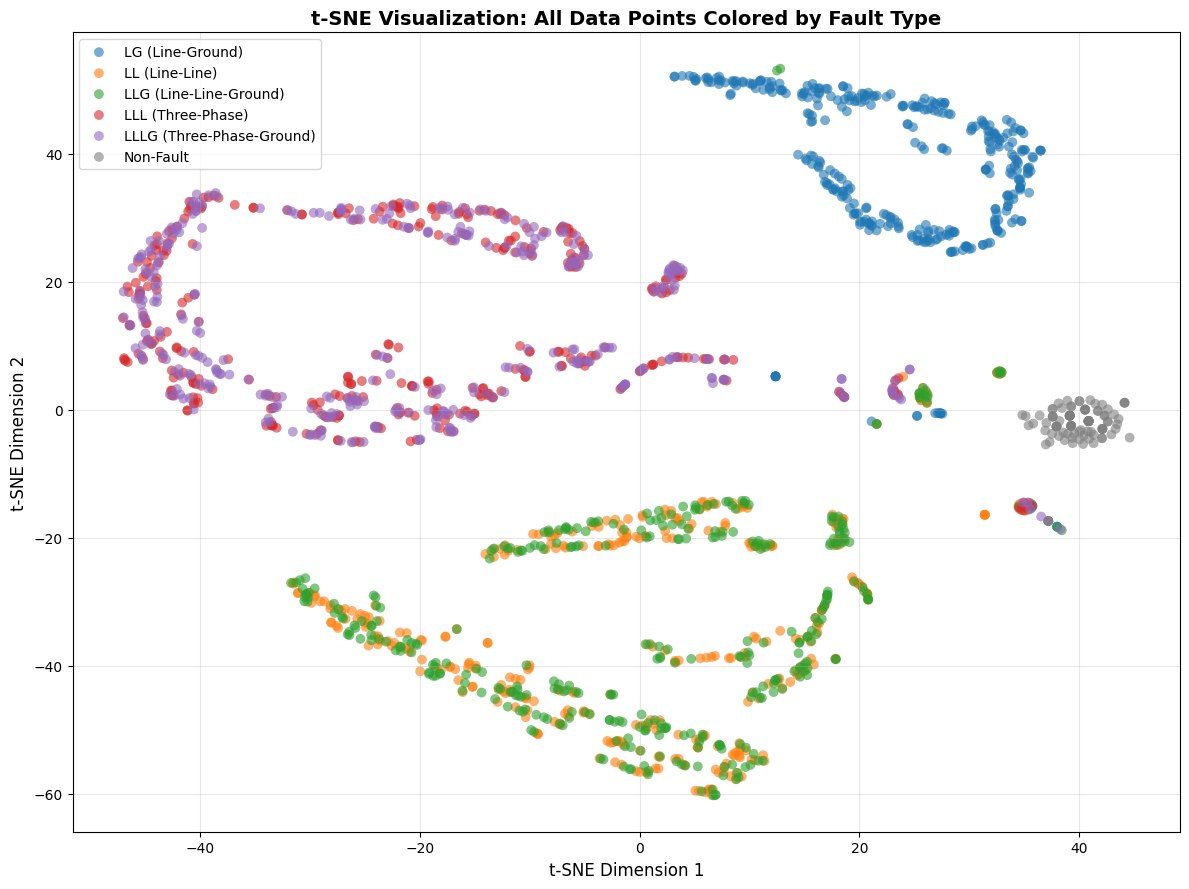

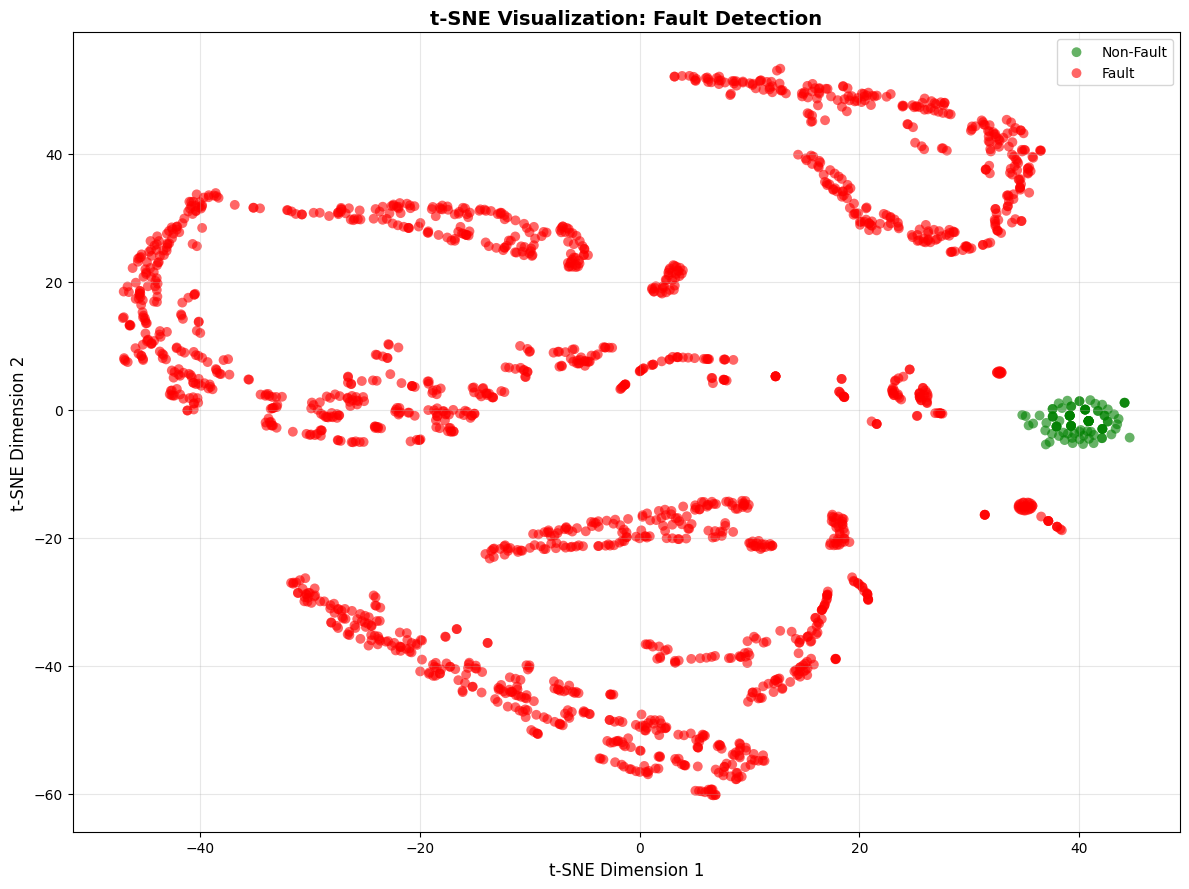

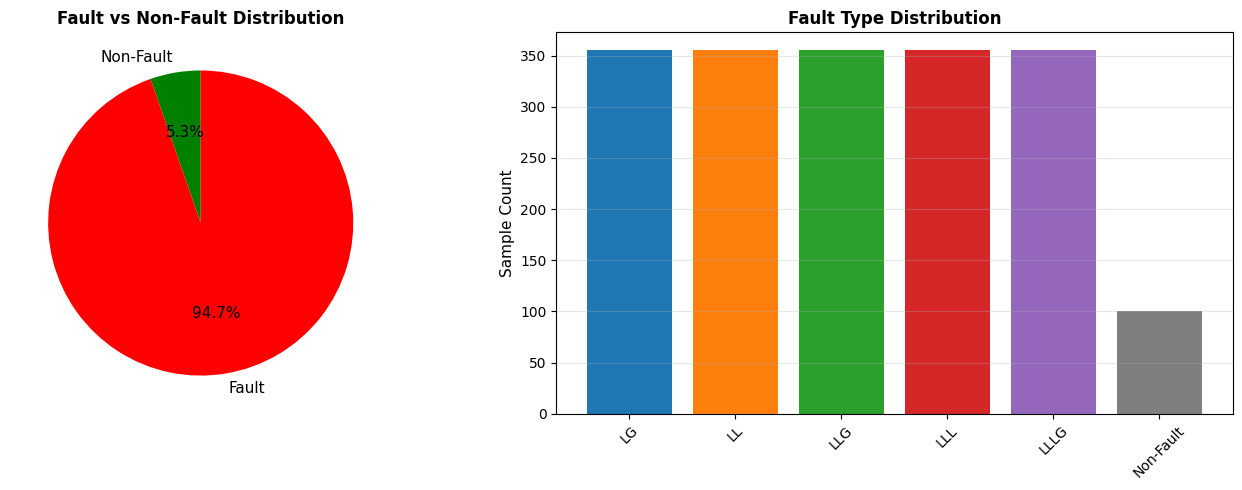

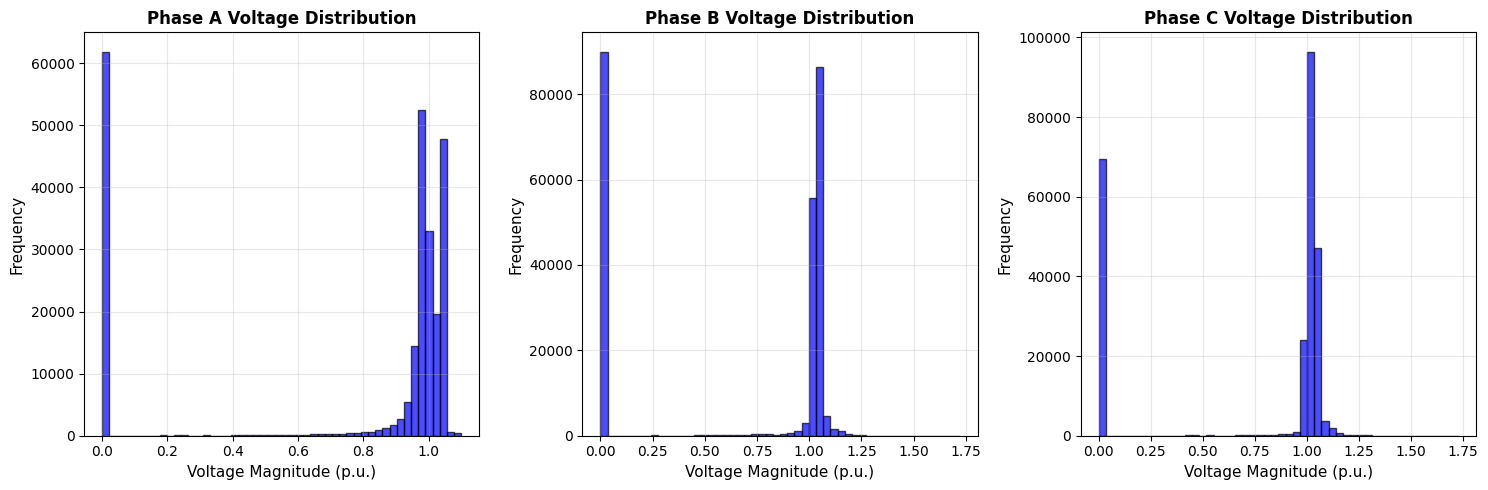


Max bus index in data: 131
Number of buses with faults: 132


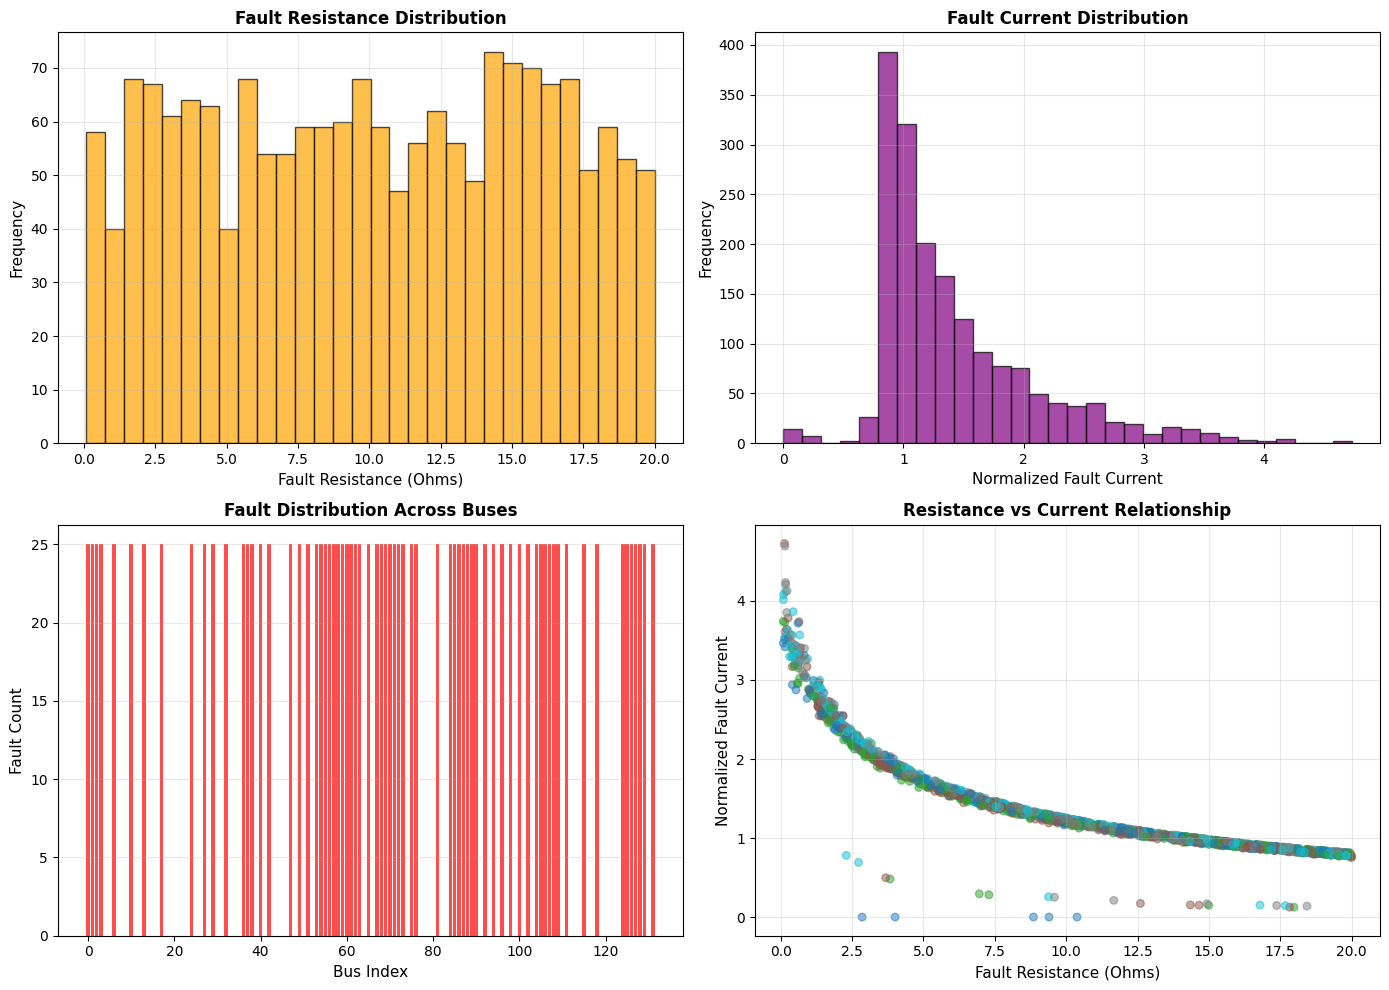


DATASET SUMMARY STATISTICS
                         Metric   Value
                  Total Samples    1875
                  Fault Samples    1775
              Non-Fault Samples     100
                    Total Buses     132
     Mean Voltage Magnitude (A)  0.7428
     Mean Voltage Magnitude (B)  0.6558
     Mean Voltage Magnitude (C)  0.7354
   Mean Fault Resistance (Ohms) 10.1033
Mean Fault Current (normalized)  1.4182


In [83]:
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd

# ==========================================
# 1. LOAD THE SAVED FILES
# ==========================================
X_dataset = np.load("/content/X_dataset.npy")
Y_dataset = np.load("/content/Y_dataset.npy")

with open("/content/bus_mapping.json", "r") as f:
    bus_mapping = json.load(f)

print("Data loaded successfully!")
print(f"X_dataset shape: {X_dataset.shape}")  # (samples, 132, 6)
print(f"Y_dataset shape: {Y_dataset.shape}")  # (samples, 5)
print(f"Number of bus nodes: {len(bus_mapping)}")

# ==========================================
# 2. PARSE THE LABELS
# ==========================================
# Y format: [Detect, Loc_Index, Type, Res, Current]
detection = Y_dataset[:, 0].astype(int)  # 0 or 1
location = Y_dataset[:, 1].astype(int)    # Bus index
fault_type = Y_dataset[:, 2].astype(int)  # 0=LG, 1=LL, 2=LLG, 3=LLL, 4=LLLG, 5=Non-Fault
resistance = Y_dataset[:, 3]              # Ohms
current = Y_dataset[:, 4]                 # Normalized

# Map fault type numbers to names
fault_type_names = {
    0: 'LG (Line-Ground)',
    1: 'LL (Line-Line)',
    2: 'LLG (Line-Line-Ground)',
    3: 'LLL (Three-Phase)',
    4: 'LLLG (Three-Phase-Ground)',
    5: 'Non-Fault'
}

fault_labels = np.array([fault_type_names[ft] for ft in fault_type])

print("\n--- Dataset Statistics ---")
print(f"Total samples: {len(X_dataset)}")
print(f"Fault samples: {np.sum(detection == 1)}")
print(f"Non-fault samples: {np.sum(detection == 0)}")
print("\nFault type distribution:")
for ft_id, ft_name in fault_type_names.items():
    count = np.sum(fault_type == ft_id)
    print(f"  {ft_name}: {count}")

# ==========================================
# 3. RESHAPE DATA FOR t-SNE
# ==========================================
# Flatten from (samples, 132, 6) to (samples, 792)
X_flat = X_dataset.reshape(X_dataset.shape[0], -1)

print(f"\nFlattened X shape for t-SNE: {X_flat.shape}")

# ==========================================
# 4. COMPUTE t-SNE
# ==========================================
print("\nComputing t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_flat)

print("t-SNE computation complete!")

# ==========================================
# 5. CREATE VISUALIZATIONS
# ==========================================

# Color palette for fault types
colors = {
    'LG (Line-Ground)': '#1f77b4',           # Blue
    'LL (Line-Line)': '#ff7f0e',             # Orange
    'LLG (Line-Line-Ground)': '#2ca02c',     # Green
    'LLL (Three-Phase)': '#d62728',          # Red
    'LLLG (Three-Phase-Ground)': '#9467bd',  # Purple
    'Non-Fault': '#7f7f7f'                   # Gray
}

# Figure 1: t-SNE colored by Fault Type
fig, ax = plt.subplots(figsize=(12, 9))

for fault_name, color in colors.items():
    mask = fault_labels == fault_name
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, label=fault_name, alpha=0.6, s=50, edgecolors='none')

ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax.set_title('t-SNE Visualization: All Data Points Colored by Fault Type', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 2: t-SNE colored by Detection (Fault vs Non-Fault)
fig, ax = plt.subplots(figsize=(12, 9))

fault_mask = detection == 1
nonfault_mask = detection == 0

ax.scatter(X_tsne[nonfault_mask, 0], X_tsne[nonfault_mask, 1],
           c='green', label='Non-Fault', alpha=0.6, s=50, edgecolors='none')
ax.scatter(X_tsne[fault_mask, 0], X_tsne[fault_mask, 1],
           c='red', label='Fault', alpha=0.6, s=50, edgecolors='none')

ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax.set_title('t-SNE Visualization: Fault Detection', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 3: Dataset Statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart: Fault vs Non-Fault
fault_counts = [np.sum(detection == 0), np.sum(detection == 1)]
axes[0].pie(fault_counts, labels=['Non-Fault', 'Fault'], autopct='%1.1f%%',
            colors=['green', 'red'], startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Fault vs Non-Fault Distribution', fontsize=12, fontweight='bold')

# Bar chart: Fault type distribution
fault_type_counts = [np.sum(fault_type == i) for i in range(6)]
axes[1].bar(range(6), fault_type_counts, color=[colors[fault_type_names[i]] for i in range(6)])
axes[1].set_xticks(range(6))
axes[1].set_xticklabels([fault_type_names[i].split()[0] for i in range(6)], rotation=45)
axes[1].set_ylabel('Sample Count', fontsize=11)
axes[1].set_title('Fault Type Distribution', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Figure 4: Voltage magnitudes per phase
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

phases = ['Phase A', 'Phase B', 'Phase C']
mag_indices = [0, 2, 4]  # Magnitude indices for A, B, C

for idx, phase_name in enumerate(phases):
    mag_data = X_dataset[:, :, mag_indices[idx]]  # (samples, 132)
    axes[idx].hist(mag_data.flatten(), bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[idx].set_xlabel('Voltage Magnitude (p.u.)', fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'{phase_name} Voltage Distribution', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Figure 5: Fault characteristics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Resistance distribution (faults only)
fault_mask = detection == 1
axes[0, 0].hist(resistance[fault_mask], bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Fault Resistance (Ohms)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Fault Resistance Distribution', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Current distribution (faults only)
axes[0, 1].hist(current[fault_mask], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Normalized Fault Current', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Fault Current Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Fault location heatmap (which buses have most faults)
# Fix: Check the actual max bus index first
max_bus_idx = int(np.max(location[fault_mask]))
num_buses_in_data = max_bus_idx + 1
print(f"\nMax bus index in data: {max_bus_idx}")
print(f"Number of buses with faults: {num_buses_in_data}")

bus_fault_count = np.zeros(num_buses_in_data)
for bus_idx in location[fault_mask]:
    bus_idx_int = int(bus_idx)
    if 0 <= bus_idx_int < num_buses_in_data:
        bus_fault_count[bus_idx_int] += 1

axes[1, 0].bar(range(num_buses_in_data), bus_fault_count, color='red', alpha=0.7)
axes[1, 0].set_xlabel('Bus Index', fontsize=11)
axes[1, 0].set_ylabel('Fault Count', fontsize=11)
axes[1, 0].set_title('Fault Distribution Across Buses', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Resistance vs Current scatter
axes[1, 1].scatter(resistance[fault_mask], current[fault_mask],
                   alpha=0.5, s=30, c=fault_type[fault_mask], cmap='tab10')
axes[1, 1].set_xlabel('Fault Resistance (Ohms)', fontsize=11)
axes[1, 1].set_ylabel('Normalized Fault Current', fontsize=11)
axes[1, 1].set_title('Resistance vs Current Relationship', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Figure 6: Summary Statistics Table
print("\n" + "="*60)
print("DATASET SUMMARY STATISTICS")
print("="*60)

summary_data = {
    'Metric': [
        'Total Samples',
        'Fault Samples',
        'Non-Fault Samples',
        'Total Buses',
        'Mean Voltage Magnitude (A)',
        'Mean Voltage Magnitude (B)',
        'Mean Voltage Magnitude (C)',
        'Mean Fault Resistance (Ohms)',
        'Mean Fault Current (normalized)'
    ],
    'Value': [
        f'{len(X_dataset)}',
        f'{np.sum(detection == 1)}',
        f'{np.sum(detection == 0)}',
        f'{len(bus_mapping)}',
        f'{X_dataset[:, :, 0].mean():.4f}',
        f'{X_dataset[:, :, 2].mean():.4f}',
        f'{X_dataset[:, :, 4].mean():.4f}',
        f'{resistance[fault_mask].mean():.4f}',
        f'{current[fault_mask].mean():.4f}'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("="*60)

### Generated Files

The following files have been generated and saved to the `/content/` directory:

- `X_dataset.npy`: Contains the feature matrix (voltage magnitudes and angles).
- `Y_dataset.npy`: Contains the labels (fault detection, location, type, resistance, and normalized current).
- `bus_mapping.json`: Maps bus indices to their original bus names, useful for interpreting the labels.

You can view these files in the Colab file browser (the folder icon on the left sidebar).

We need to define the model and train it


Loading dataset...
Data loaded successfully!
X shape: (1875, 132, 6)
Y shape: (1875, 5)
Number of bus nodes: 132
Train set: (1500, 132, 6)
Test set: (375, 132, 6)

Number of training batches: 47
Number of testing batches: 12

Using device: cpu

Total model parameters: 57,966

STARTING TRAINING

Epoch [50/500]
  Train Loss: 7.049287 | Test Loss: 6.041348
  Tasks (L1, L2, L3, L4, L5):
    Train: ['0.147739', '4.014131', '1.649729', '23.437387', '0.200226']
    Test:  ['0.078467', '4.091676', '1.612401', '13.112664', '0.119880']

Epoch [100/500]
  Train Loss: 6.437087 | Test Loss: 5.802548
  Tasks (L1, L2, L3, L4, L5):
    Train: ['0.126142', '3.966131', '1.632381', '17.863396', '0.185960']
    Test:  ['0.064745', '4.053154', '1.597834', '11.134076', '0.197983']

Epoch [150/500]
  Train Loss: 6.132994 | Test Loss: 5.544267
  Tasks (L1, L2, L3, L4, L5):
    Train: ['0.114018', '3.913897', '1.615107', '15.408012', '0.158457']
    Test:  ['0.063585', '4.052019', '1.598796', '8.587204', '0.10

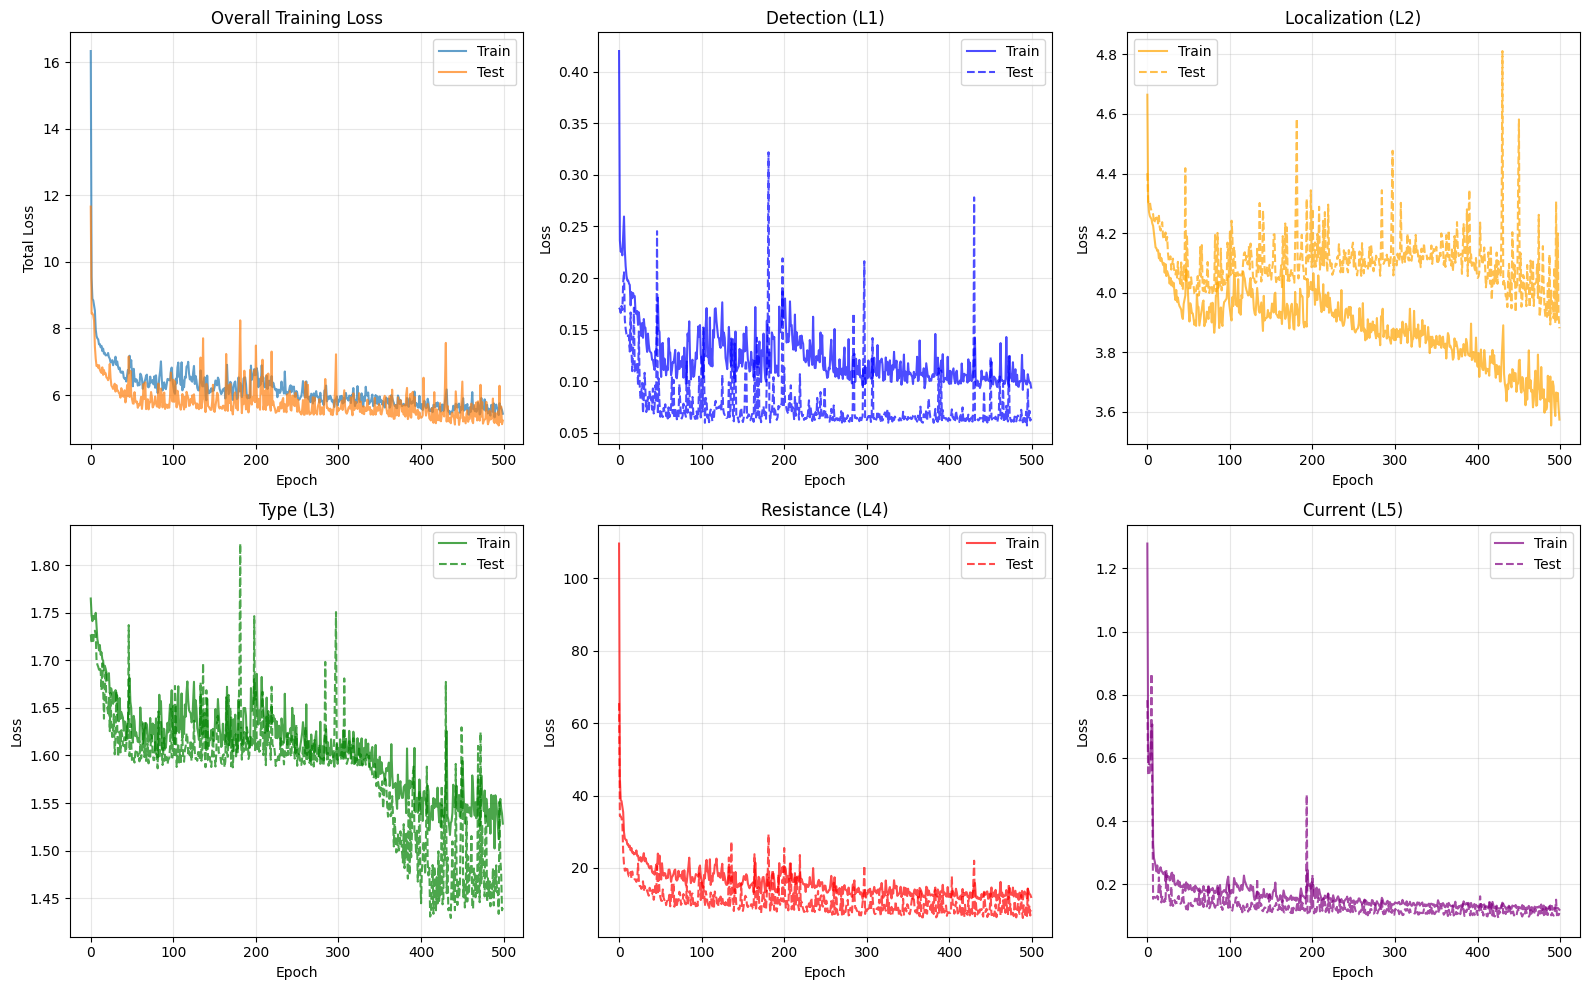


✓ Model training and saving complete!


In [85]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.nn import GCNConv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import json

# ==========================================
# 1. LOAD DATA
# ==========================================
print("Loading dataset...")
try:
    X_dataset = np.load("/content/X_dataset.npy")  # (samples, 132, 6)
    Y_dataset = np.load("/content/Y_dataset.npy")  # (samples, 5)

    with open("/content/bus_mapping.json", "r") as f:
        bus_mapping = json.load(f)

    print("Data loaded successfully!")
    print(f"X shape: {X_dataset.shape}")
    print(f"Y shape: {Y_dataset.shape}")
    print(f"Number of bus nodes: {len(bus_mapping)}")

    # Split into train and test (80-20)
    X_train, X_test, Y_train, Y_test = train_test_split(
        X_dataset, Y_dataset, test_size=0.2, random_state=66
    )

    print(f"Train set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")

    # Convert to tensors
    X_train = torch.FloatTensor(X_train)
    Y_train = torch.FloatTensor(Y_train)
    X_test = torch.FloatTensor(X_test)
    Y_test = torch.FloatTensor(Y_test)

    # Create data loaders
    batch_size = 32
    train_dataset = TensorDataset(X_train, Y_train)
    test_dataset = TensorDataset(X_test, Y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"\nNumber of training batches: {len(train_loader)}")
    print(f"Number of testing batches: {len(test_loader)}")

except FileNotFoundError:
    print("ERROR: Dataset files (X_dataset.npy, Y_dataset.npy, bus_mapping.json) not found.")
    print("Please ensure that the data generation cell (sfF-orcoVtve) has been fixed and executed successfully.")
    print("Specifically, in cell sfF-orcoVtve, add 'dss_circuit = dss_engine.ActiveCircuit' right after the 'dss_text.Command(\"Compile /content/IEEE123Master.dss\")' line.")
    print("Then run cell sfF-orcoVtve again, and after that, re-run this cell (O8K5UZGrdLtX).")
    raise SystemExit("Exiting due to missing dataset files.")

# ==========================================
# 2. BUILD FULLY CONNECTED GNN-INSPIRED ARCHITECTURE
# ==========================================
# Since we don't have explicit graph structure, we'll use a dense network
# that mimics GNN with multiple heads (as per the paper architecture)

class MTL_GNN(nn.Module):
    """
    Multi-Task Learning Graph Neural Network
    - Detection Head: Binary classification (Fault / Non-Fault)
    - Localization Head: 128-way classification (which bus)
    - Type Head: 6-way classification (fault type)
    - Resistance Head: Regression (fault resistance in Ohms)
    - Current Head: Regression (normalized fault current)
    """

    def __init__(self, input_dim=792, hidden_dim=32, num_buses=132, num_types=6):
        super(MTL_GNN, self).__init__()

        # Input: (batch, 132, 6) -> flatten to (batch, 792)
        self.input_dim = input_dim

        # ========== GNN BACKBONE ==========
        # GCNConv1: 792 -> 32 channels
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)

        # GCNConv2: 32 -> 32 channels
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.ln2 = nn.LayerNorm(hidden_dim)

        # GCNConv3: 32 -> 32 channels
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)

        # Concatenation layer output: 32 (from last layer)
        concat_dim = hidden_dim

        # ========== CLASSIFICATION HEADS ==========
        # Fault Detection Head: Binary (Fault / Non-Fault)
        self.detection_head = nn.Sequential(
            nn.Linear(concat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)  # 2 classes
        )

        # Fault Localization Head: 132-way (which bus)
        self.localization_head = nn.Sequential(
            nn.Linear(concat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_buses)  # 132 buses
        )

        # Fault Type Classification Head: 6-way
        self.type_head = nn.Sequential(
            nn.Linear(concat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_types)  # 6 types (LG, LL, LLG, LLL, LLLG, Non-Fault)
        )

        # ========== REGRESSION HEADS ==========
        # Fault Resistance Estimation Head
        self.resistance_head = nn.Sequential(
            nn.Linear(concat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)  # Continuous value
        )

        # Fault Current Estimation Head
        self.current_head = nn.Sequential(
            nn.Linear(concat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)  # Continuous value
        )

        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        """
        Forward pass through GNN backbone and task heads
        Input: x of shape (batch, 132, 6)
        Output: tuple of (detection, localization, type, resistance, current)
        """
        # Flatten input
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1)  # (batch, 792)

        # ========== GNN BACKBONE ==========
        # Layer 1: GCNConv
        h1 = self.fc1(x)
        h1 = self.ln1(h1)
        h1 = F.relu(h1)
        h1 = self.dropout(h1)

        # Layer 2: GCNConv
        h2 = self.fc2(h1)
        h2 = self.ln2(h2)
        h2 = F.relu(h2)
        h2 = self.dropout(h2)

        # Layer 3: GCNConv
        h3 = self.fc3(h2)
        h3 = F.relu(h3)

        # Use h3 as the concatenated features for all heads
        features = h3

        # ========== TASK HEADS ==========
        detection_out = self.detection_head(features)          # (batch, 2)
        localization_out = self.localization_head(features)    # (batch, 132)
        type_out = self.type_head(features)                    # (batch, 6)
        resistance_out = self.resistance_head(features)        # (batch, 1)
        current_out = self.current_head(features)              # (batch, 1)

        return detection_out, localization_out, type_out, resistance_out, current_out


# ==========================================
# 3. LOSS FUNCTION & TRAINING SETUP
# ==========================================

class MTL_Loss(nn.Module):
    """
    Multi-Task Learning Loss with weighted combination
    Loss weights: (0.01, 0.8, 0.9, 0.1, 0.04, 0.05)
    """
    def __init__(self, w=(0.01, 0.8, 0.9, 0.1, 0.04, 0.05)):
        super(MTL_Loss, self).__init__()
        self.w = w

        self.detection_loss = nn.CrossEntropyLoss()
        self.localization_loss = nn.CrossEntropyLoss()
        self.type_loss = nn.CrossEntropyLoss()
        self.resistance_loss = nn.MSELoss()
        self.current_loss = nn.MSELoss()

    def forward(self, predictions, targets):
        """
        predictions: tuple of (detection, localization, type, resistance, current)
        targets: (batch, 5) where targets[:, 0]=detection, targets[:, 1]=location, etc.
        """
        detection_pred, loc_pred, type_pred, res_pred, curr_pred = predictions

        # Extract targets
        detect_target = targets[:, 0].long()        # Detection (0 or 1)
        loc_target = targets[:, 1].long()           # Location (0-131)
        type_target = targets[:, 2].long()          # Type (0-5)
        res_target = targets[:, 3].unsqueeze(1)     # Resistance (continuous)
        curr_target = targets[:, 4].unsqueeze(1)    # Current (continuous)

        # Calculate individual losses
        L1 = self.detection_loss(detection_pred, detect_target)
        L2 = self.localization_loss(loc_pred, loc_target)
        L3 = self.type_loss(type_pred, type_target)
        L4 = self.resistance_loss(res_pred, res_target)
        L5 = self.current_loss(curr_pred, curr_target)

        # Weighted sum
        total_loss = (self.w[0] * L1 +
                      self.w[1] * L2 +
                      self.w[2] * L3 +
                      self.w[3] * L4 +
                      self.w[4] * L5)

        return total_loss, (L1, L2, L3, L4, L5)


# ==========================================
# 4. TRAINING FUNCTION
# ==========================================

def train_epoch(model, train_loader, optimizer, criterion, device, gradient_clip=5):
    """Train for one epoch with gradient clipping"""
    model.train()
    total_loss = 0
    task_losses = [0, 0, 0, 0, 0]

    for X_batch, Y_batch in train_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        # Forward pass
        predictions = model(X_batch)
        loss, individual_losses = criterion(predictions, Y_batch)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)

        optimizer.step()

        total_loss += loss.item()
        for i, l in enumerate(individual_losses):
            task_losses[i] += l.item()

    avg_loss = total_loss / len(train_loader)
    avg_task_losses = [l / len(train_loader) for l in task_losses]

    return avg_loss, avg_task_losses


def evaluate(model, test_loader, criterion, device):
    """Evaluate model on test set"""
    model.eval()
    total_loss = 0
    task_losses = [0, 0, 0, 0, 0]

    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            predictions = model(X_batch)
            loss, individual_losses = criterion(predictions, Y_batch)

            total_loss += loss.item()
            for i, l in enumerate(individual_losses):
                task_losses[i] += l.item()

    avg_loss = total_loss / len(test_loader)
    avg_task_losses = [l / len(test_loader) for l in task_losses]

    return avg_loss, avg_task_losses


# ==========================================
# 5. MAIN TRAINING LOOP
# ==========================================

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Initialize model
model = MTL_GNN(input_dim=X_dataset.shape[1] * X_dataset.shape[2], hidden_dim=32, num_buses=len(bus_mapping), num_types=6).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal model parameters: {total_params:,}")

# Loss function and optimizer
criterion = MTL_Loss(w=(0.01, 0.8, 0.9, 0.1, 0.04, 0.05))
optimizer = AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-3
)

# Training parameters
num_epochs = 500
gradient_clip = 5

# History tracking
history = {
    'train_loss': [],
    'test_loss': [],
    'train_task_losses': [[], [], [], [], []],
    'test_task_losses': [[], [], [], [], []]
}

print("\n" + "="*80)
print("STARTING TRAINING")
print("="*80)

for epoch in range(num_epochs):
    train_loss, train_task_loss = train_epoch(
        model, train_loader, optimizer, criterion, device, gradient_clip
    )
    test_loss, test_task_loss = evaluate(model, test_loader, criterion, device)

    # Store history
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    for i in range(5):
        history['train_task_losses'][i].append(train_task_loss[i])
        history['test_task_losses'][i].append(test_task_loss[i])

    # Print progress
    if (epoch + 1) % 50 == 0:
        print(f"\nEpoch [{epoch+1}/{num_epochs}]")
        print(f"  Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")
        print(f"  Tasks (L1, L2, L3, L4, L5):")
        print(f"    Train: {[f'{l:.6f}' for l in train_task_loss]}")
        print(f"    Test:  {[f'{l:.6f}' for l in test_task_loss]}")

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)

# ==========================================
# 6. SAVE MODEL
# ==========================================

model_save_path = "/content/mtl_gnn_model.pt"
torch.save(model.state_dict(), model_save_path)
print(f"\nModel saved to: {model_save_path}")

# Save model config for inference
config = {
    'input_dim': X_dataset.shape[1] * X_dataset.shape[2],
    'hidden_dim': 32,
    'num_buses': len(bus_mapping),
    'num_types': 6,
    'total_parameters': total_params
}

with open("/content/model_config.json", "w") as f:
    json.dump(config, f, indent=4)

print(f"Model config saved to: /content/model_config.json")

# ==========================================
# 7. PLOT TRAINING HISTORY
# ==========================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Overall loss
axes[0, 0].plot(history['train_loss'], label='Train', alpha=0.7)
axes[0, 0].plot(history['test_loss'], label='Test', alpha=0.7)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('Overall Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

task_names = ['Detection (L1)', 'Localization (L2)', 'Type (L3)', 'Resistance (L4)', 'Current (L5)']
colors = ['blue', 'orange', 'green', 'red', 'purple']

# Individual task losses
for i in range(5):
    row = (i + 1) // 3
    col = (i + 1) % 3

    axes[row, col].plot(history['train_task_losses'][i], label='Train', alpha=0.7, color=colors[i])
    axes[row, col].plot(history['test_task_losses'][i], label='Test', alpha=0.7,
                        color=colors[i], linestyle='--')
    axes[row, col].set_xlabel('Epoch')
    axes[row, col].set_ylabel('Loss')
    axes[row, col].set_title(task_names[i])
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
print(f"Training history plot saved to: /content/training_history.png")
plt.show()

print("\n✓ Model training and saving complete!")


Max bus index in data: 131
Number of buses with faults: 132


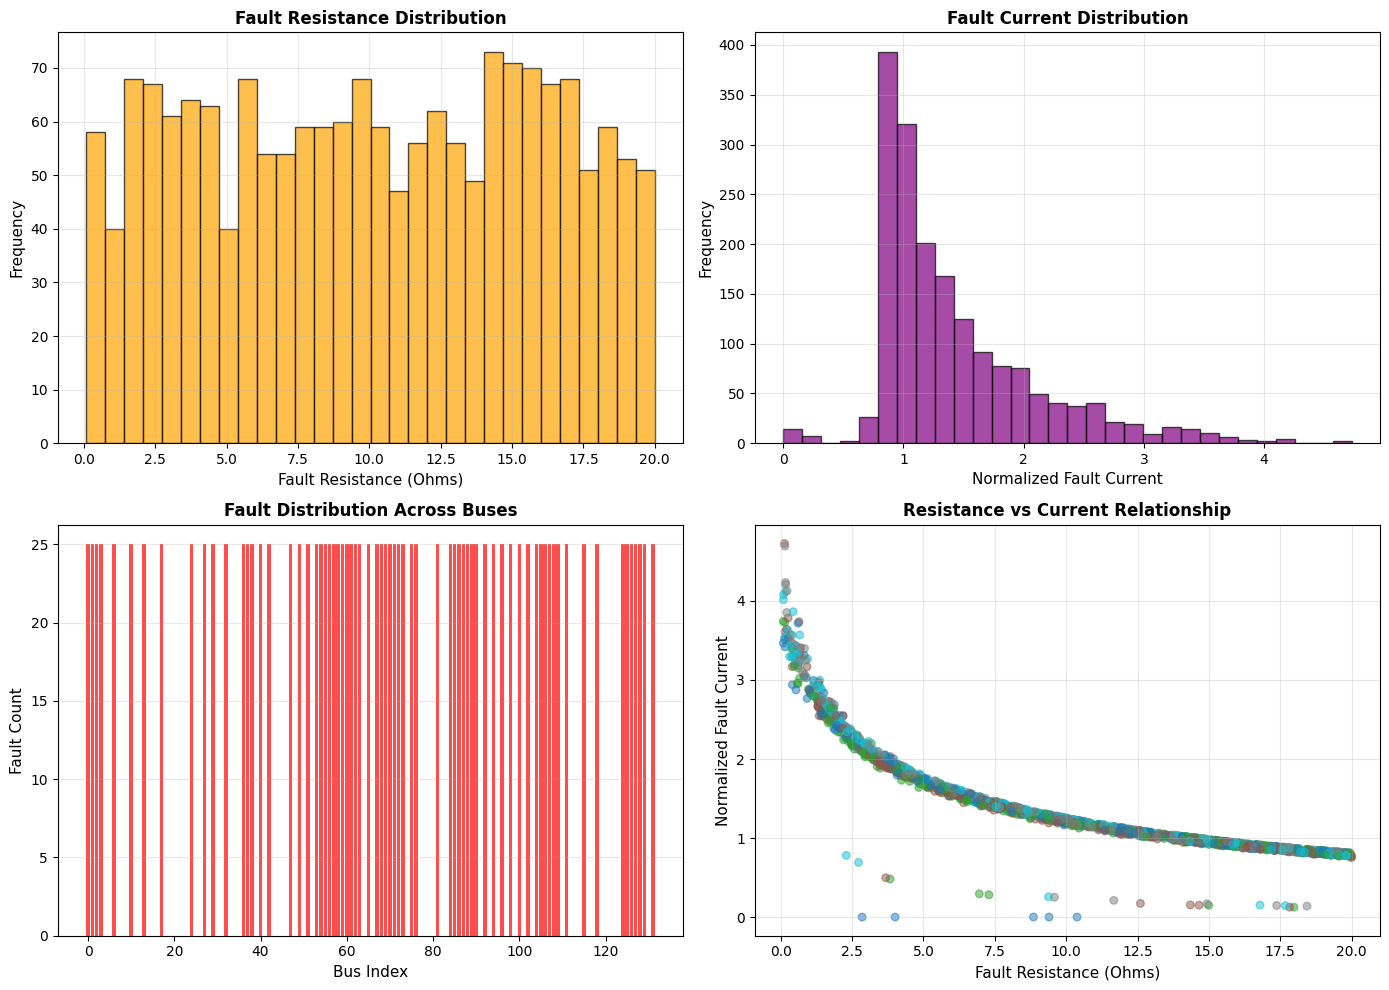

In [86]:
# Figure 5: Fault characteristics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Resistance distribution (faults only)
fault_mask = detection == 1
axes[0, 0].hist(resistance[fault_mask], bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Fault Resistance (Ohms)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Fault Resistance Distribution', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Current distribution (faults only)
axes[0, 1].hist(current[fault_mask], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Normalized Fault Current', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Fault Current Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Fault location heatmap (which buses have most faults)
# Fix: Check the actual max bus index first
max_bus_idx = int(np.max(location[fault_mask]))
num_buses_in_data = max_bus_idx + 1
print(f"\nMax bus index in data: {max_bus_idx}")
print(f"Number of buses with faults: {num_buses_in_data}")

bus_fault_count = np.zeros(num_buses_in_data)
for bus_idx in location[fault_mask]:
    bus_idx_int = int(bus_idx)
    if 0 <= bus_idx_int < num_buses_in_data:
        bus_fault_count[bus_idx_int] += 1

axes[1, 0].bar(range(num_buses_in_data), bus_fault_count, color='red', alpha=0.7)
axes[1, 0].set_xlabel('Bus Index', fontsize=11)
axes[1, 0].set_ylabel('Fault Count', fontsize=11)
axes[1, 0].set_title('Fault Distribution Across Buses', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Resistance vs Current scatter
axes[1, 1].scatter(resistance[fault_mask], current[fault_mask],
                   alpha=0.5, s=30, c=fault_type[fault_mask], cmap='tab10')
axes[1, 1].set_xlabel('Fault Resistance (Ohms)', fontsize=11)
axes[1, 1].set_ylabel('Normalized Fault Current', fontsize=11)
axes[1, 1].set_title('Resistance vs Current Relationship', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

SyntaxError: incomplete input (4183629205.py, line 19)

In [4]:
"""
Inference Script for MTL-GNN Model
Load the trained model and make predictions on new data
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import json

# ==========================================
# 1. LOAD MODEL ARCHITECTURE (same as training)
# ==========================================

class MTL_GNN(nn.Module):
    """
    Multi-Task Learning Graph Neural Network
    """

    def __init__(self, input_dim=768, hidden_dim=32, num_buses=128, num_types=6):
        super(MTL_GNN, self).__init__()

        self.input_dim = input_dim

        # GNN BACKBONE
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)

        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.ln2 = nn.LayerNorm(hidden_dim)

        self.fc3 = nn.Linear(hidden_dim, hidden_dim)

        concat_dim = hidden_dim

        # CLASSIFICATION HEADS
        self.detection_head = nn.Sequential(
            nn.Linear(concat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

        self.localization_head = nn.Sequential(
            nn.Linear(concat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_buses)
        )

        self.type_head = nn.Sequential(
            nn.Linear(concat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_types)
        )

        # REGRESSION HEADS
        self.resistance_head = nn.Sequential(
            nn.Linear(concat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

        self.current_head = nn.Sequential(
            nn.Linear(concat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1)

        # GNN BACKBONE
        h1 = self.fc1(x)
        h1 = self.ln1(h1)
        h1 = F.relu(h1)
        h1 = self.dropout(h1)

        h2 = self.fc2(h1)
        h2 = self.ln2(h2)
        h2 = F.relu(h2)
        h2 = self.dropout(h2)

        h3 = self.fc3(h2)
        h3 = F.relu(h3)

        features = h3

        # TASK HEADS
        detection_out = self.detection_head(features)
        localization_out = self.localization_head(features)
        type_out = self.type_head(features)
        resistance_out = self.resistance_head(features)
        current_out = self.current_head(features)

        return detection_out, localization_out, type_out, resistance_out, current_out


# ==========================================
# 2. MODEL INFERENCE CLASS
# ==========================================

class MTL_GNN_Predictor:
    """Wrapper class for model inference"""

    def __init__(self, model_path="/content/mtl_gnn_model_best.pt",
                 config_path="/content/model_config.json",
                 device=None):

        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = device

        # Load config
        with open(config_path, "r") as f:
            self.config = json.load(f)

        # Initialize model
        self.model = MTL_GNN(
            input_dim=self.config['input_dim'],
            hidden_dim=self.config['hidden_dim'],
            num_buses=self.config['num_buses'],
            num_types=self.config['num_types']
        ).to(self.device)

        # Load weights
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.eval()

        # Define mappings
        self.fault_type_map = {
            0: 'LG (Line-Ground)',
            1: 'LL (Line-Line)',
            2: 'LLG (Line-Line-Ground)',
            3: 'LLL (Three-Phase)',
            4: 'LLLG (Three-Phase-Ground)',
            5: 'Non-Fault'
        }

        print(f"Model loaded successfully on {self.device}")
        print(f"Total parameters: {self.config['total_parameters']:,}")

    def predict(self, X):
        """
        Make prediction on input data

        Args:
            X: numpy array of shape (batch, 128, 6) or (128, 6)

        Returns:
            Dictionary with predictions for all tasks
        """
        # Handle single sample
        if X.ndim == 2:
            X = np.expand_dims(X, axis=0)

        # Convert to tensor
        X_tensor = torch.FloatTensor(X).to(self.device)

        with torch.no_grad():
            detection_out, loc_out, type_out, res_out, curr_out = self.model(X_tensor)

        # Process outputs
        batch_size = X.shape[0]
        predictions = []

        for i in range(batch_size):
            pred_dict = {}

            # Detection (Binary classification)
            detection_probs = F.softmax(detection_out[i], dim=0)
            detection_class = torch.argmax(detection_out[i]).item()
            pred_dict['detection'] = {
                'class': detection_class,
                'is_fault': detection_class == 1,
                'confidence': detection_probs[detection_class].item()
            }

            # Localization (Which bus)
            loc_probs = F.softmax(loc_out[i], dim=0)
            loc_bus = torch.argmax(loc_out[i]).item()
            pred_dict['localization'] = {
                'bus_index': loc_bus,
                'confidence': loc_probs[loc_bus].item()
            }

            # Fault Type
            type_probs = F.softmax(type_out[i], dim=0)
            type_class = torch.argmax(type_out[i]).item()
            pred_dict['fault_type'] = {
                'type': self.fault_type_map[type_class],
                'type_id': type_class,
                'confidence': type_probs[type_class].item()
            }

            # Fault Resistance (Regression)
            resistance_value = res_out[i].item()
            pred_dict['resistance'] = {
                'value_ohms': max(0, resistance_value),  # Ensure non-negative
            }

            # Fault Current (Regression)
            current_value = curr_out[i].item()
            pred_dict['current'] = {
                'normalized_value': current_value,
            }

            predictions.append(pred_dict)

        return predictions if len(predictions) > 1 else predictions[0]

    def predict_with_probabilities(self, X):
        """
        Return raw probabilities for all classes

        Args:
            X: numpy array of shape (batch, 128, 6) or (128, 6)

        Returns:
            Dictionary with raw probabilities
        """
        if X.ndim == 2:
            X = np.expand_dims(X, axis=0)

        X_tensor = torch.FloatTensor(X).to(self.device)

        with torch.no_grad():
            detection_out, loc_out, type_out, res_out, curr_out = self.model(X_tensor)

        batch_size = X.shape[0]
        predictions = []

        for i in range(batch_size):
            pred_dict = {}

            # Detection probabilities
            detection_probs = F.softmax(detection_out[i], dim=0).cpu().numpy()
            pred_dict['detection_probs'] = {
                'non_fault': float(detection_probs[0]),
                'fault': float(detection_probs[1])
            }

            # Localization probabilities (top 10)
            loc_probs = F.softmax(loc_out[i], dim=0).cpu().numpy()
            top_10_idx = np.argsort(loc_probs)[::-1][:10]
            pred_dict['localization_top_10'] = [
                {
                    'bus_index': int(idx),
                    'probability': float(loc_probs[idx])
                }
                for idx in top_10_idx
            ]

            # Fault type probabilities
            type_probs = F.softmax(type_out[i], dim=0).cpu().numpy()
            pred_dict['fault_type_probs'] = {
                self.fault_type_map[j]: float(type_probs[j])
                for j in range(len(self.fault_type_map))
            }

            # Regression outputs
            pred_dict['resistance_value'] = float(res_out[i].item())
            pred_dict['current_value'] = float(curr_out[i].item())

            predictions.append(pred_dict)

        return predictions if len(predictions) > 1 else predictions[0]


# ==========================================
# 3. EXAMPLE USAGE
# ==========================================

if __name__ == "__main__":
    print("="*80)
    print("MTL-GNN INFERENCE EXAMPLE")
    print("="*80)

    # Load test data
    X_test = np.load("/content/X_dataset.npy")[:10]  # First 10 samples

    # Initialize predictor
    predictor = MTL_GNN_Predictor()

    # Make predictions
    print("\nMaking predictions on 10 test samples...\n")
    predictions = predictor.predict(X_test)

    # Display results
    for idx, pred in enumerate(predictions):
        print(f"Sample {idx}:")
        print(f"  Detection: {'FAULT' if pred['detection']['is_fault'] else 'NON-FAULT'} "
              f"(confidence: {pred['detection']['confidence']:.4f})")
        print(f"  Fault Location: Bus {pred['localization']['bus_index']} "
              f"(confidence: {pred['localization']['confidence']:.4f})")
        print(f"  Fault Type: {pred['fault_type']['type']} "
              f"(confidence: {pred['fault_type']['confidence']:.4f})")
        print(f"  Resistance: {pred['resistance']['value_ohms']:.2f} Ω")
        print(f"  Current: {pred['current']['normalized_value']:.4f}")
        print()

    # Get probabilities
    print("\nDetailed probability analysis for first sample:\n")
    prob_pred = predictor.predict_with_probabilities(X_test[0])

    print("Detection Probabilities:")
    for class_name, prob in prob_pred['detection_probs'].items():
        print(f"  {class_name}: {prob:.4f}")

    print("\nTop 10 Bus Locations:")
    for loc in prob_pred['localization_top_10']:
        print(f"  Bus {loc['bus_index']}: {loc['probability']:.4f}")

    print("\nFault Type Probabilities:")
    for fault_type, prob in prob_pred['fault_type_probs'].items():
        print(f"  {fault_type}: {prob:.4f}")

MTL-GNN INFERENCE EXAMPLE
Model loaded successfully on cpu
Total parameters: 57,966

Making predictions on 10 test samples...

Sample 0:
  Detection: FAULT (confidence: 0.5354)
  Fault Location: Bus 0 (confidence: 0.5898)
  Fault Type: Non-Fault (confidence: 0.4700)
  Resistance: 5.46 Ω
  Current: 0.6025

Sample 1:
  Detection: FAULT (confidence: 0.5354)
  Fault Location: Bus 0 (confidence: 0.5898)
  Fault Type: Non-Fault (confidence: 0.4700)
  Resistance: 5.46 Ω
  Current: 0.6026

Sample 2:
  Detection: FAULT (confidence: 0.5354)
  Fault Location: Bus 0 (confidence: 0.5898)
  Fault Type: Non-Fault (confidence: 0.4700)
  Resistance: 5.46 Ω
  Current: 0.6026

Sample 3:
  Detection: FAULT (confidence: 0.5354)
  Fault Location: Bus 0 (confidence: 0.5898)
  Fault Type: Non-Fault (confidence: 0.4700)
  Resistance: 5.46 Ω
  Current: 0.6026

Sample 4:
  Detection: FAULT (confidence: 0.5354)
  Fault Location: Bus 0 (confidence: 0.5898)
  Fault Type: Non-Fault (confidence: 0.4700)
  Resistance: